# LIBRARY

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
from collections import Counter
import scipy
import pandas as pd
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np


In [13]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, classification_report,
                             roc_curve, auc)
import numpy as np
import matplotlib.pyplot as plt

In [14]:
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE

In [15]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [16]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.calibration import CalibratedClassifierCV  # ← needed for predict_proba
import numpy as np

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report

In [18]:
def print_dist(y, label, binary=False):
    unique, counts = np.unique(y, return_counts=True)
    proportions    = counts / counts.sum()
    prefix         = 'binary=' if binary else 'sii='
    df = pd.DataFrame({
        'Class':      [f'{prefix}{u}' for u in unique],
        'Count':      counts,
        'Proportion': proportions.round(4),
        'Percentage': (proportions * 100).round(2)
    })
    print(f"\n{'='*60}")
    print(f"  SET: {label}")
    print(df.to_string(index=False))

# READ DATAFRAME

In [19]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"

df=pd.read_csv(file_path)

In [20]:
df

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
0,0,5,0,16.877316,46.000,50.800000,82.152821,4.611111,17.883041,6.500000,2.0,2.668550,1492.000000,41.586230,9.213770,1.0,19.541300,32.690900,2.0
1,1,9,0,14.035590,48.000,46.000000,90.666667,8.000000,18.204545,11.000000,2.0,2.579490,1498.650000,42.029150,3.970850,1.0,15.410700,27.055200,0.0
2,2,10,1,16.648696,56.500,75.600000,82.333333,27.000000,12.450000,10.000000,3.0,3.389932,1796.890000,59.788250,15.811750,2.0,25.634700,42.380000,0.0
3,3,9,0,18.292347,56.000,81.600000,79.000000,23.000000,18.204545,7.000000,3.0,3.841910,1923.440000,62.775700,18.824300,2.0,26.479800,45.996600,1.0
4,4,18,1,17.937682,54.626,76.139461,90.152104,12.000000,26.463732,8.003205,3.0,12.054014,2652.510000,60.327711,15.811750,2.0,29.912400,42.380000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8377,8455,7,1,16.130585,46.070,48.700252,81.861037,6.500000,18.075000,7.000000,1.0,2.625946,1490.847845,45.526276,3.173977,1.0,18.024600,31.583004,0.0
8378,8456,10,1,17.300000,56.130,77.531978,79.833333,8.500000,13.575000,5.000000,3.0,4.987853,1678.330810,69.880763,7.651215,1.0,22.983200,36.475662,1.0
8379,8457,10,1,40.937571,49.560,143.030726,82.166667,21.500000,16.840263,9.500000,4.0,3.990512,1547.346725,107.979706,35.051020,2.0,31.594712,35.106855,0.0
8380,8458,15,1,22.500000,63.790,130.236404,88.395702,10.000000,26.417470,10.500000,2.0,4.967841,1674.735823,103.517750,26.718654,2.0,46.467581,57.530686,2.0


In [21]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8382, 17)
y shape : (8382,)
Classes : [0. 1. 2. 3.]
Class counts : {0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85}


# Data Preparation

In [22]:
X.shape

(8382, 17)

In [23]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5794, 1567,  936,   85], dtype=int64))

In [24]:
Counter(y)

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

In [25]:
ctr = Counter(y)
ctr

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

## Data Partitioning

In [26]:
from sklearn.model_selection import train_test_split, cross_val_score 

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [28]:
X_train.shape

(5867, 17)

In [29]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0., 1., 2., 3.]), array([4056, 1097,  655,   59], dtype=int64)),
 (array([0., 1., 2., 3.]), array([1738,  470,  281,   26], dtype=int64)))

In [30]:
np.max(np.unique(y_train, return_counts=True)[1])/len(X_train)

0.6913243565706494

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [32]:

print(f"Train samples : {len(y_train)}")
print(f"Test samples  : {len(y_test)}")

Train samples : 5867
Test samples  : 2515


# CASCADE LINEAR SVM

## model

In [33]:
param_list = [
    # l2 + hinge — requires dual=True
    {
        'C':            [0.001,0.01, 0.1, 1, 10],
        'penalty':      ['l1', 'l2'],
        'class_weight': ['balanced']
    }
]

In [34]:
def train_one_step_svm(X_train, y_binary, X_test, y_test_binary, step_name,
                       n_iter=50, n_splits=5, random_state=0):

    print(f"\n{'='*60}")
    print(f"  STEP: {step_name}")
    print(f"  Training samples : {len(y_binary)}")
    print(f"  Positive class   : {y_binary.sum()} samples")
    print(f"  Negative class   : {(y_binary==0).sum()} samples")
    print(f"{'='*60}")

    # ── Random search on LinearSVC ────────────────────────────────────────────
    # NOTE: search on LinearSVC directly (faster)
    # calibration is applied AFTER finding best params
    random_search = RandomizedSearchCV(
        LinearSVC(random_state=random_state),
        param_distributions=param_list,
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring='f1_macro',
        n_jobs=-1,
        refit=True,
        n_iter=n_iter,
        random_state=random_state,
        error_score='raise',
    )
    random_search.fit(X_train, y_binary)

    print(f"\n  Best params : {random_search.best_params_}")
    print(f"  Best CV F1  : {random_search.best_score_:.4f}")

    # ── Wrap best model with calibration to enable predict_proba ─────────────
    # LinearSVC has no predict_proba natively
    # CalibratedClassifierCV adds it via Platt scaling
    calibrated_model = CalibratedClassifierCV(
        LinearSVC(**random_search.best_params_,
                  random_state=random_state),
        cv=5
    )
    calibrated_model.fit(X_train, y_binary)

    # ── Predictions ───────────────────────────────────────────────────────────
    y_pred_binary = calibrated_model.predict(X_test)
    y_proba       = calibrated_model.predict_proba(X_test)[:, 1]  # P(positive)

    test_f1 = f1_score(y_test_binary, y_pred_binary, average='weighted')
    print(f"  Test F1     : {test_f1:.4f}")

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm   = confusion_matrix(y_test_binary, y_pred_binary)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f'not {step_name}', step_name]
    )
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {step_name}')
    plt.tight_layout()
    plt.show()

    # ── ROC curve ─────────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
    roc_auc     = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='#7F77DD', linewidth=2,
             label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {step_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # ── Reports ───────────────────────────────────────────────────────────────
    print(classification_report(y_test_binary, y_pred_binary,
                                target_names=[f'not {step_name}', step_name]))

    print(f"\n  Confusion Matrix breakdown:")
    print(f"    TN (correct negatives) : {cm[0,0]}")
    print(f"    FP (false positives)   : {cm[0,1]}")
    print(f"    FN (false negatives)   : {cm[1,0]}")
    print(f"    TP (correct positives) : {cm[1,1]}")
    print(f"    AUC                    : {roc_auc:.4f}")

    return calibrated_model     # ← return calibrated model, not raw LinearSVC

## split 

In [35]:
# 
step_results = {}   
y_pred_final = np.full(len(X_test), -1)
original_idx = np.arange(len(X_test))

# Working copies that shrink at each cascade step
X_tr = X_train.copy()
y_tr = y_train.copy()
X_te = X_test.copy()
y_te = y_test.copy()

models  = {}
classes = np.unique(y_train)

print(f"Classes found  : {classes}")
print(f"Train samples  : {len(y_tr)}")
print(f"Test samples   : {len(y_te)}")

Classes found  : [0. 1. 2. 3.]
Train samples  : 5867
Test samples   : 2515


In [36]:
print_dist(y_tr, 'TRAIN')
print_dist(y_te, 'TEST')


  SET: TRAIN
  Class  Count  Proportion  Percentage
sii=0.0   4056      0.6913       69.13
sii=1.0   1097      0.1870       18.70
sii=2.0    655      0.1116       11.16
sii=3.0     59      0.0101        1.01

  SET: TEST
  Class  Count  Proportion  Percentage
sii=0.0   1738      0.6911       69.11
sii=1.0    470      0.1869       18.69
sii=2.0    281      0.1117       11.17
sii=3.0     26      0.0103        1.03


### class 0

In [37]:
# ── STEP 1: sii=0 vs [1, 2, 3] ───────────────────────────────────────────
y_binary_tr = (y_tr == 0).astype(int)
y_binary_te = (y_te == 0).astype(int)


In [38]:
print_dist(y_binary_tr, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   1811      0.3087       30.87
binary=1   4056      0.6913       69.13

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    777      0.3089       30.89
binary=1   1738      0.6911       69.11


In [39]:
from imblearn.over_sampling import SMOTE
over_dic={0:3500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 4056, 0: 3500})


In [40]:
print_dist(y_res, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   3500      0.4632       46.32
binary=1   4056      0.5368       53.68

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    777      0.3089       30.89
binary=1   1738      0.6911       69.11



  STEP: sii=0
  Training samples : 7556
  Positive class   : 4056 samples
  Negative class   : 3500 samples


c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 10 is smaller than n_iter=50. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



  Best params : {'penalty': 'l1', 'class_weight': 'balanced', 'C': 1}
  Best CV F1  : 0.6232


c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  Test F1     : 0.6604


c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


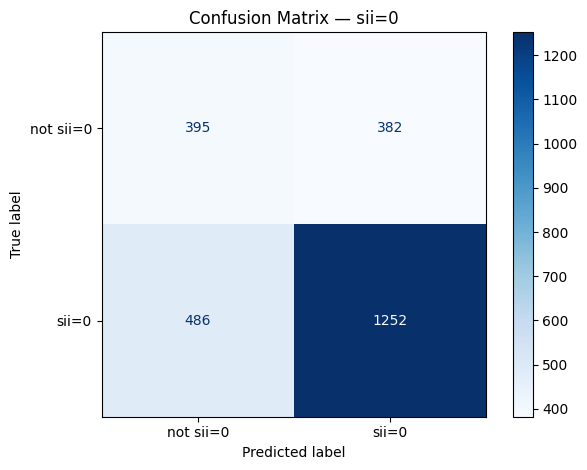

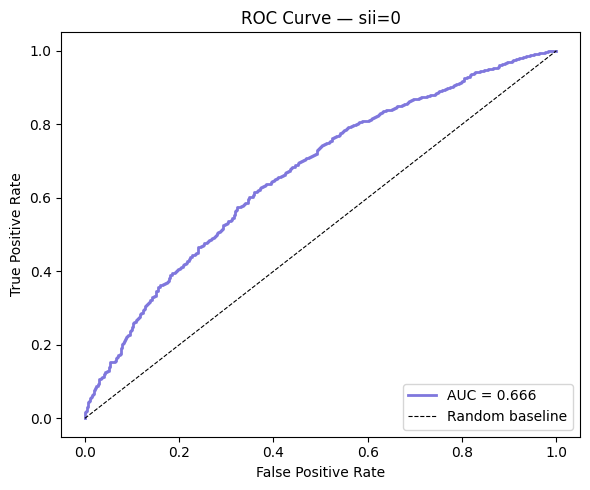

              precision    recall  f1-score   support

   not sii=0       0.45      0.51      0.48       777
       sii=0       0.77      0.72      0.74      1738

    accuracy                           0.65      2515
   macro avg       0.61      0.61      0.61      2515
weighted avg       0.67      0.65      0.66      2515


  Confusion Matrix breakdown:
    TN (correct negatives) : 395
    FP (false positives)   : 382
    FN (false negatives)   : 486
    TP (correct positives) : 1252
    AUC                    : 0.6664


In [41]:
models[0] = train_one_step_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=0')

In [42]:
# samples predicted as sii=0 → assign 0 to their original position
y_pred_te   = models[0].predict(X_te)

#----------------------------------
step_results[0] = {
    'step_name':    'sii=0 vs [1,2,3]',
    'y_true_bin':   y_binary_te.copy(),      # verdadero binario
    'y_pred_bin':   y_pred_te.copy(),        # predicho binario
    'y_true_orig':  y_te.copy(),             # verdadero multiclass en este paso
    'original_idx': original_idx.copy(),     # índices originales
}

y_pred_final[original_idx[y_pred_te == 1]] = 0

print(f"\n  Assigned as sii=0 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=0 : 1634 samples


### class 1 

In [43]:
# TRAIN → remove all true sii=0 
mask_tr      = y_tr != 0
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink index tracker too

In [44]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 1')
print_dist(y_te, 'TEST  after step 1')

  Remaining train : 1811
  Remaining test  : 1263

  SET: TRAIN after step 1
  Class  Count  Proportion  Percentage
sii=1.0   1097      0.6057       60.57
sii=2.0    655      0.3617       36.17
sii=3.0     59      0.0326        3.26

  SET: TEST  after step 1
  Class  Count  Proportion  Percentage
sii=0.0    486      0.3848       38.48
sii=1.0    470      0.3721       37.21
sii=2.0    281      0.2225       22.25
sii=3.0     26      0.0206        2.06


In [45]:
y_binary_tr = (y_tr == 1).astype(int)
y_binary_te = (y_te == 1).astype(int)

In [46]:
print_dist(y_binary_tr, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    714      0.3943       39.43
binary=1   1097      0.6057       60.57

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    793      0.6279       62.79
binary=1    470      0.3721       37.21


In [47]:
from imblearn.over_sampling import SMOTE
over_dic={0:900}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 1097, 0: 900})


In [48]:
print_dist(y_res, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    900      0.4507       45.07
binary=1   1097      0.5493       54.93

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    793      0.6279       62.79
binary=1    470      0.3721       37.21



  STEP: sii=1
  Training samples : 1997
  Positive class   : 1097 samples
  Negative class   : 900 samples

  Best params : {'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.01}
  Best CV F1  : 0.5802


c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 10 is smaller than n_iter=50. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Test F1     : 0.5134


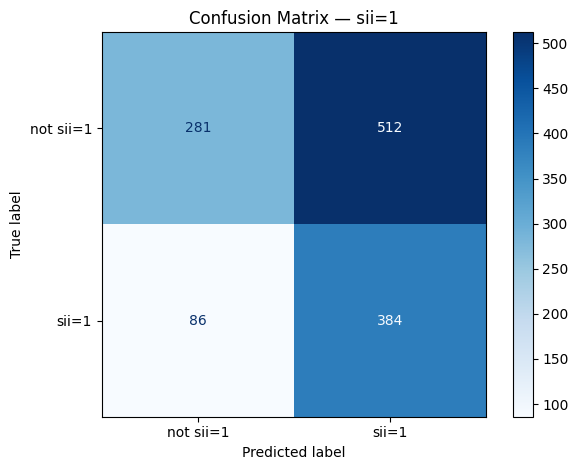

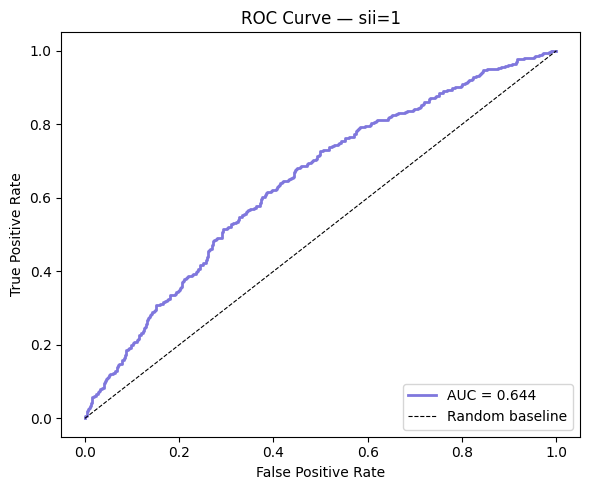

              precision    recall  f1-score   support

   not sii=1       0.77      0.35      0.48       793
       sii=1       0.43      0.82      0.56       470

    accuracy                           0.53      1263
   macro avg       0.60      0.59      0.52      1263
weighted avg       0.64      0.53      0.51      1263


  Confusion Matrix breakdown:
    TN (correct negatives) : 281
    FP (false positives)   : 512
    FN (false negatives)   : 86
    TP (correct positives) : 384
    AUC                    : 0.6439


In [49]:
models[1] = train_one_step_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=1')

In [50]:
y_pred_te   = models[1].predict(X_te)

step_results[1] = {
    'step_name':    'sii=1 vs [2,3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 1

print(f"\n  Assigned as sii=1 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=1 : 896 samples


### class 2

In [51]:
# TRAIN → remove all true sii=1
mask_tr      = y_tr != 1
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES 
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

In [52]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 2')
print_dist(y_te, 'TEST  after step 2')

  Remaining train : 714
  Remaining test  : 879

  SET: TRAIN after step 2
  Class  Count  Proportion  Percentage
sii=2.0    655      0.9174       91.74
sii=3.0     59      0.0826        8.26

  SET: TEST  after step 2
  Class  Count  Proportion  Percentage
sii=0.0    486      0.5529       55.29
sii=1.0     86      0.0978        9.78
sii=2.0    281      0.3197       31.97
sii=3.0     26      0.0296        2.96


(714, 17) (714, 2)


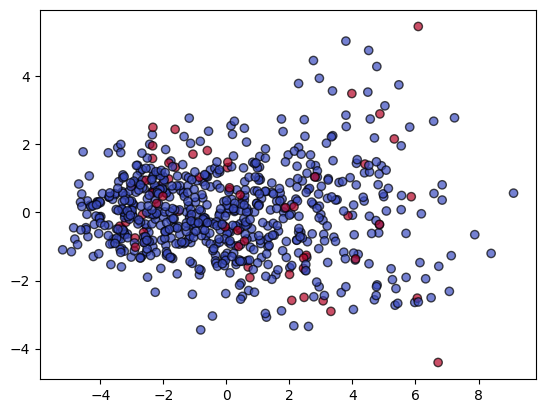

In [53]:
from sklearn.decomposition import PCA
def plot_pca(X_pca, y_train):
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolor='k', alpha=0.7)
    plt.show()
pca = PCA(n_components=2)
pca.fit(X_tr)
X_pca = pca.transform(X_tr)
print(X_tr.shape, X_pca.shape)
plot_pca(X_pca, y_tr)

In [54]:
y_binary_tr = (y_tr == 2).astype(int)
y_binary_te = (y_te == 2).astype(int)

In [55]:
print_dist(y_binary_tr, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0     59      0.0826        8.26
binary=1    655      0.9174       91.74

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    598      0.6803       68.03
binary=1    281      0.3197       31.97


In [56]:
from imblearn.over_sampling import SMOTE
over_dic={0:500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))


Resampled dataset shape Counter({1: 655, 0: 500})


In [57]:
print_dist(y_res, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0    500      0.4329       43.29
binary=1    655      0.5671       56.71

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    598      0.6803       68.03
binary=1    281      0.3197       31.97



  STEP: sii=2
  Training samples : 1155
  Positive class   : 655 samples
  Negative class   : 500 samples

  Best params : {'penalty': 'l1', 'class_weight': 'balanced', 'C': 1}
  Best CV F1  : 0.6482


c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 10 is smaller than n_iter=50. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  Test F1     : 0.3814


c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


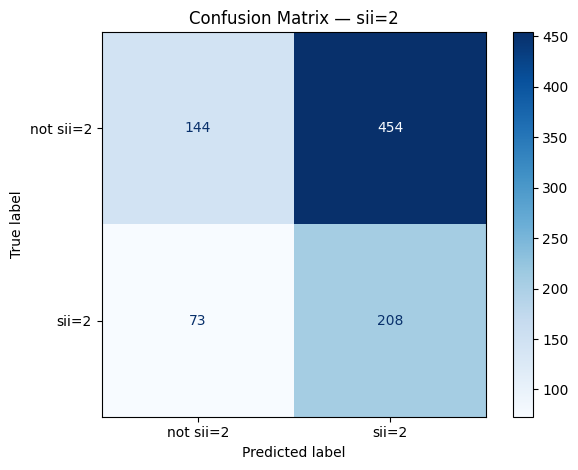

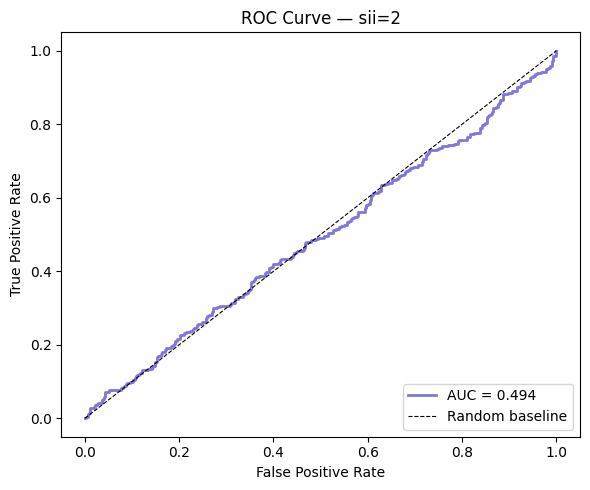

              precision    recall  f1-score   support

   not sii=2       0.66      0.24      0.35       598
       sii=2       0.31      0.74      0.44       281

    accuracy                           0.40       879
   macro avg       0.49      0.49      0.40       879
weighted avg       0.55      0.40      0.38       879


  Confusion Matrix breakdown:
    TN (correct negatives) : 144
    FP (false positives)   : 454
    FN (false negatives)   : 73
    TP (correct positives) : 208
    AUC                    : 0.4935


In [58]:
models[2] = train_one_step_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=2')

In [59]:
# ── Assign predictions for step 3 ────────────────────────────────────────────
y_pred_te   = models[2].predict(X_te)

step_results[2] = {
    'step_name':    'sii=2 vs [3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 2

print(f"\n  Assigned as sii=2 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=2 : 662 samples


### class 3 

In [60]:
# ── Filter for next step ──────────────────────────────────────────────────────
mask_tr      = y_tr != 2
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")

  Remaining train : 59
  Remaining test  : 671


In [61]:
y_pred_final[original_idx] = 3
step_results[3] = {
    'step_name':    'sii=3 (remaining)',
    'y_true_bin':   (y_te == 3).astype(int),
    'y_pred_bin':   np.ones(len(y_te), dtype=int),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

print(f"\n  Assigned as sii=3 : {len(original_idx)} samples (all remaining)")


  Assigned as sii=3 : 671 samples (all remaining)


## RESULTS

In [62]:
# ══════════════════════════════════════════════════════════════════════════════
# REPORTE COMBINADO
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "="*75)
print("  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS")
print("="*75)

rows = []
for step, res in step_results.items():
    yt = res['y_true_bin']
    yp = res['y_pred_bin']

    # métricas binarias reales de cada paso
    prec   = precision_score(yt, yp, zero_division=0)
    rec    = recall_score(yt, yp, zero_division=0)
    f1     = f1_score(yt, yp, zero_division=0)
    n      = len(yt)
    n_pos  = yt.sum()
    tp     = ((yp == 1) & (yt == 1)).sum()
    fp     = ((yp == 1) & (yt == 0)).sum()
    fn     = ((yp == 0) & (yt == 1)).sum()

    rows.append({
        'Step':         res['step_name'],
        'N samples':    n,
        'N positive':   n_pos,
        'TP':           tp,
        'FP':           fp,
        'FN':           fn,
        'Precision':    round(prec, 4),
        'Recall':       round(rec,  4),
        'F1':           round(f1,   4),
    })

report_df = pd.DataFrame(rows)
print(report_df.to_string(index=False))


  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS
             Step  N samples  N positive   TP  FP  FN  Precision  Recall     F1
 sii=0 vs [1,2,3]       2515        1738 1252 382 486     0.7662  0.7204 0.7426
   sii=1 vs [2,3]       1263         470  384 512  86     0.4286  0.8170 0.5622
     sii=2 vs [3]        879         281  208 454  73     0.3142  0.7402 0.4411
sii=3 (remaining)        671          26   26 645   0     0.0387  1.0000 0.0746


In [63]:
# ── Multiclass final ──────────────────────────────────────────────────────────
print("\n" + "="*75)
print("  FINAL MULTICLASS REPORT (y_test vs y_pred_final)")
print("="*75)
print(classification_report(
    y_test, y_pred_final,
    target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']
))


  FINAL MULTICLASS REPORT (y_test vs y_pred_final)
              precision    recall  f1-score   support

       sii=0       1.00      0.72      0.84      1738
       sii=1       1.00      0.82      0.90       470
       sii=2       1.00      0.74      0.85       281
       sii=3       0.04      1.00      0.07        26

    accuracy                           0.74      2515
   macro avg       0.76      0.82      0.67      2515
weighted avg       0.99      0.74      0.84      2515



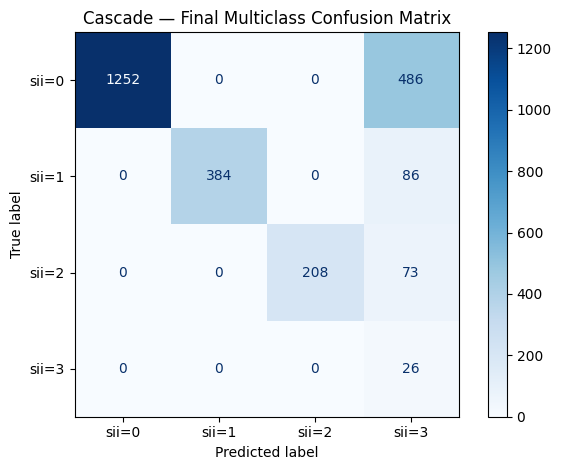

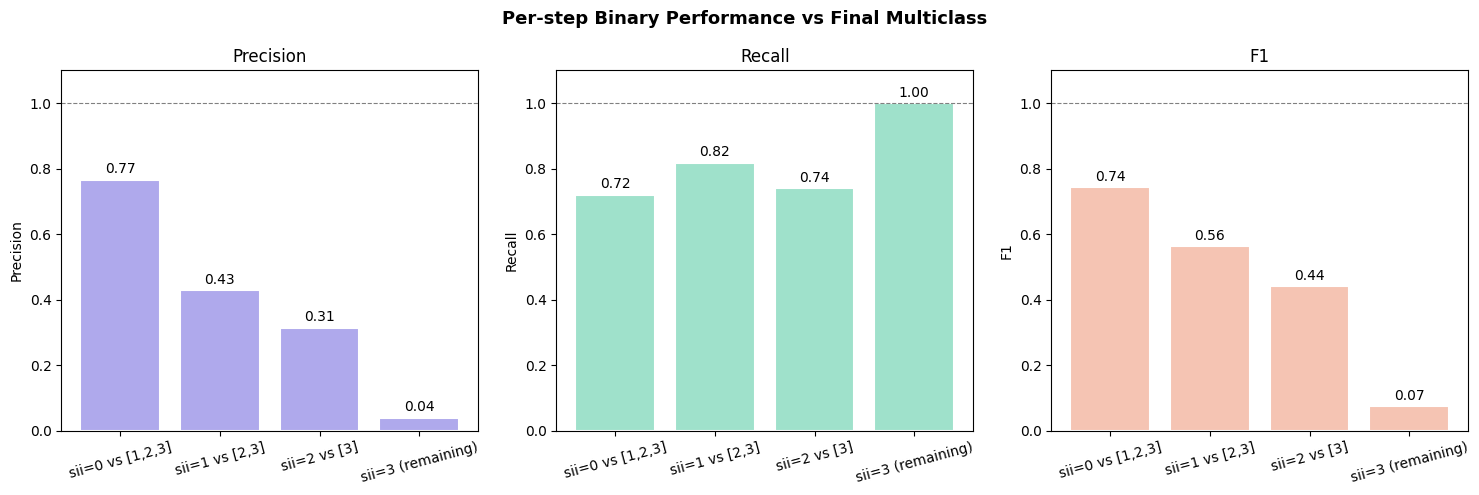

In [64]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['sii=0', 'sii=1', 'sii=2', 'sii=3']
)
disp.plot(cmap='Blues')
plt.title('Cascade — Final Multiclass Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Plot comparativo ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['Precision', 'Recall', 'F1']
colors    = ['#AFA9EC', '#9FE1CB', '#F5C4B3']

for ax, metric, color in zip(axes, metrics, colors):
    steps  = [r['Step'] for r in rows]
    values = [r[metric] for r in rows]
    bars   = ax.bar(steps, values, color=color, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle('Per-step Binary Performance vs Final Multiclass',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [65]:
# ── Per class summary ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  PREDICTIONS SUMMARY")
print(f"{'='*60}")
for cls in [0, 1, 2, 3]:
    true_count = (y_test == cls).sum()
    pred_count = (y_pred_final == cls).sum()
    print(f"  sii={cls} → true: {true_count:<6} predicted: {pred_count}")


  PREDICTIONS SUMMARY
  sii=0 → true: 1738   predicted: 1252
  sii=1 → true: 470    predicted: 384
  sii=2 → true: 281    predicted: 208
  sii=3 → true: 26     predicted: 671


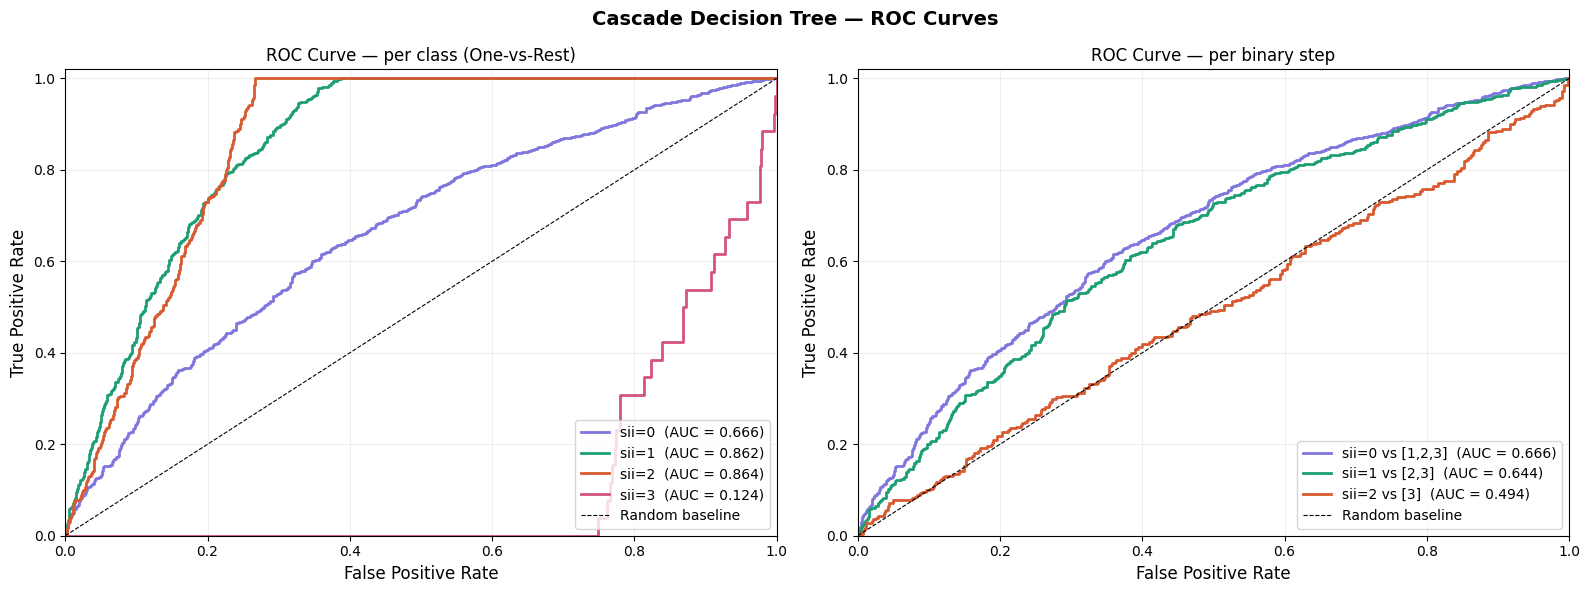


  AUC SUMMARY
  sii=0    → AUC = 0.6664
  sii=1    → AUC = 0.8619
  sii=2    → AUC = 0.8644
  sii=3    → AUC = 0.1237

  Macro AUC    : 0.6291
  Weighted AUC : 0.7194


In [66]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Collect probabilities from each step ───────────────────────────────────
# Each model gives P(class=X) for the samples it saw
# We need to reconstruct full probability matrix (n_test, 4)

n_test     = len(X_test)
proba_full = np.zeros((n_test, 4))   # one column per class

for step, res in step_results.items():
    idx    = res['original_idx']          # which original test samples this step saw
    model  = models.get(step)

    if model is not None:
        proba_step         = model.predict_proba(X_test[idx])   # shape (n_step, 2)
        proba_full[idx, step] = proba_step[:, 1]                # P(positive) for this class
    else:
        # last class — use survival probability (1 - sum of previous)
        proba_full[idx, step] = 1 - proba_full[idx, :step].sum(axis=1)

# ── 2. Binarize y_test for multiclass ROC ────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # shape (n_test, 4)

# ── 3. Compute ROC per class ──────────────────────────────────────────────────
colors     = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E']
step_names = ['sii=0', 'sii=1', 'sii=2', 'sii=3']

fpr_dict = {}
tpr_dict = {}
auc_dict = {}

for i in range(4):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], proba_full[:, i])
    auc_dict[i]                  = auc(fpr_dict[i], tpr_dict[i])

# ── 4. Plot — two panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1 — individual ROC per class ───────────────────────────────────────
ax = axes[0]
for i in range(4):
    ax.plot(fpr_dict[i], tpr_dict[i],
            color=colors[i],
            linewidth=2,
            label=f"{step_names[i]}  (AUC = {auc_dict[i]:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per class (One-vs-Rest)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

# ── Panel 2 — step by step binary ROC ────────────────────────────────────────
ax = axes[1]
for step, res in step_results.items():
    model = models.get(step)
    if model is None:
        continue                              # skip last class (no model)

    idx        = res['original_idx']
    y_true_bin = res['y_true_bin']
    y_proba    = model.predict_proba(X_test[idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_true_bin, y_proba)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=colors[step],
            linewidth=2,
            label=f"{step_results[step]['step_name']}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per binary step', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

plt.suptitle('Cascade Decision Tree — ROC Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Print AUC summary ──────────────────────────────────────────────────────
print("\n" + "="*45)
print("  AUC SUMMARY")
print("="*45)
for i in range(4):
    print(f"  {step_names[i]:<8} → AUC = {auc_dict[i]:.4f}")

from sklearn.metrics import roc_auc_score
macro    = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='macro')
weighted = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='weighted')
print(f"\n  Macro AUC    : {macro:.4f}")
print(f"  Weighted AUC : {weighted:.4f}")
print("="*45)

# CASCADE NON LINEAR SVM

## model

In [67]:
param_list = [
    # RBF kernel — most commonly used non-linear kernel
    {
        'C':            [0.001, 0.01, 0.1, 1],#, 100],
        'kernel':       ['rbf'],
        'gamma':        ['auto'],
        'class_weight': ['balanced']
    },
    # # Polynomial kernel — good for image/text data
    {
         'C':            [0.001, 0.01, 0.1, 1],#, 100],, 100],
         'kernel':       ['poly'],
         'gamma':        ['auto'],
         'degree':       [2, 3, 4, 5],       # polynomial degree
         'coef0':        [0, 0.1, 0.5],   # independent term
         'class_weight': ['balanced'],
    },
    # # Sigmoid kernel — similar to neural network activation
    {
         'C':            [0.001, 0.01, 0.1, 1, 10],#, 100],, 100],
         'kernel':       ['sigmoid'],
         'gamma':        ['auto'],
         'coef0':        [0, 0.1, 0.5],
         'class_weight': ['balanced']
    }
]

In [68]:
def train_one_step_non_svm(X_train, y_binary, X_test, y_test_binary, step_name,
                       n_iter=50, n_splits=5, random_state=0):

    print(f"\n{'='*60}")
    print(f"  STEP: {step_name}")
    print(f"  Training samples : {len(y_binary)}")
    print(f"  Positive class   : {y_binary.sum()} samples")
    print(f"  Negative class   : {(y_binary==0).sum()} samples")
    print(f"{'='*60}")

    random_search = RandomizedSearchCV(
            SVC(probability=True, random_state=random_state),
            param_distributions=param_list,
            cv=KFold(n_splits=n_splits, shuffle=True,random_state=random_state),
            scoring='f1_weighted',
            n_jobs=-1,
            refit=True,
            n_iter=n_iter,
            random_state=random_state
    )
    random_search.fit(X_train, y_binary)

    best_model = random_search.best_estimator_
    best_model.fit(X_train, y_binary)

    print(f"\n  Best params : {random_search.best_params_}")
    print(f"  Best CV F1  : {random_search.best_score_:.4f}")

    # ── Predictions ───────────────────────────────────────────────────────────
    y_pred_binary = best_model.predict(X_test)
    y_proba       = best_model.predict_proba(X_test)[:, 1]  # ← P(positive class)
                                                             #   only 2 columns in binary

    test_f1 = f1_score(y_test_binary, y_pred_binary, average='weighted')
    print(f"  Test F1     : {test_f1:.4f}")

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm   = confusion_matrix(y_test_binary, y_pred_binary)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f'not {step_name}', step_name]
    )
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {step_name}')
    plt.tight_layout()
    plt.show()

    # ── ROC curve ─────────────────────────────────────────────────────────────
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
    roc_auc     = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='#7F77DD', linewidth=2,
             label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {step_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # ── Reports ───────────────────────────────────────────────────────────────
    print(classification_report(y_test_binary, y_pred_binary,
                                target_names=[f'not {step_name}', step_name]))

    print(f"\n  Confusion Matrix breakdown:")
    print(f"    TN (correct negatives) : {cm[0,0]}")
    print(f"    FP (false positives)   : {cm[0,1]}")
    print(f"    FN (false negatives)   : {cm[1,0]}")
    print(f"    TP (correct positives) : {cm[1,1]}")
    print(f"    AUC                    : {roc_auc:.4f}")

    return best_model

## split 

In [69]:
# 
step_results = {}   
y_pred_final = np.full(len(X_test), -1)
original_idx = np.arange(len(X_test))

# Working copies that shrink at each cascade step
X_tr = X_train.copy()
y_tr = y_train.copy()
X_te = X_test.copy()
y_te = y_test.copy()

models  = {}
classes = np.unique(y_train)

print(f"Classes found  : {classes}")
print(f"Train samples  : {len(y_tr)}")
print(f"Test samples   : {len(y_te)}")

Classes found  : [0. 1. 2. 3.]
Train samples  : 5867
Test samples   : 2515


In [70]:
print_dist(y_tr, 'TRAIN')
print_dist(y_te, 'TEST')


  SET: TRAIN
  Class  Count  Proportion  Percentage
sii=0.0   4056      0.6913       69.13
sii=1.0   1097      0.1870       18.70
sii=2.0    655      0.1116       11.16
sii=3.0     59      0.0101        1.01

  SET: TEST
  Class  Count  Proportion  Percentage
sii=0.0   1738      0.6911       69.11
sii=1.0    470      0.1869       18.69
sii=2.0    281      0.1117       11.17
sii=3.0     26      0.0103        1.03


### class 0

In [71]:
# ── STEP 1: sii=0 vs [1, 2, 3] ───────────────────────────────────────────
y_binary_tr = (y_tr == 0).astype(int)
y_binary_te = (y_te == 0).astype(int)


In [72]:
print_dist(y_binary_tr, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   1811      0.3087       30.87
binary=1   4056      0.6913       69.13

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    777      0.3089       30.89
binary=1   1738      0.6911       69.11


In [73]:
from imblearn.over_sampling import SMOTE
over_dic={0:3500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 4056, 0: 3500})


In [74]:
print_dist(y_res, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   3500      0.4632       46.32
binary=1   4056      0.5368       53.68

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    777      0.3089       30.89
binary=1   1738      0.6911       69.11



  STEP: sii=0
  Training samples : 7556
  Positive class   : 4056 samples
  Negative class   : 3500 samples



  Best params : {'kernel': 'poly', 'gamma': 'auto', 'degree': 5, 'coef0': 0.5, 'class_weight': 'balanced', 'C': 1}
  Best CV F1  : 0.6707
  Test F1     : 0.6127


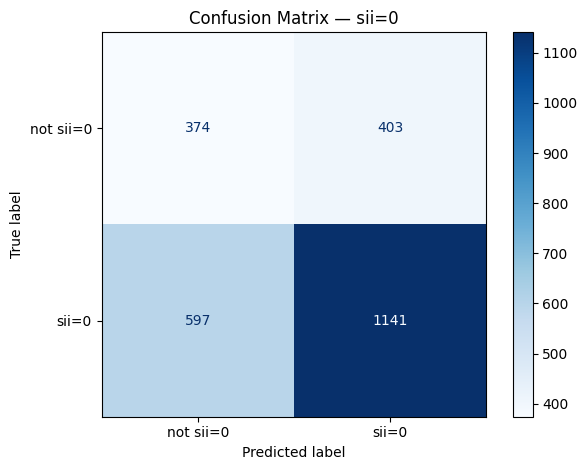

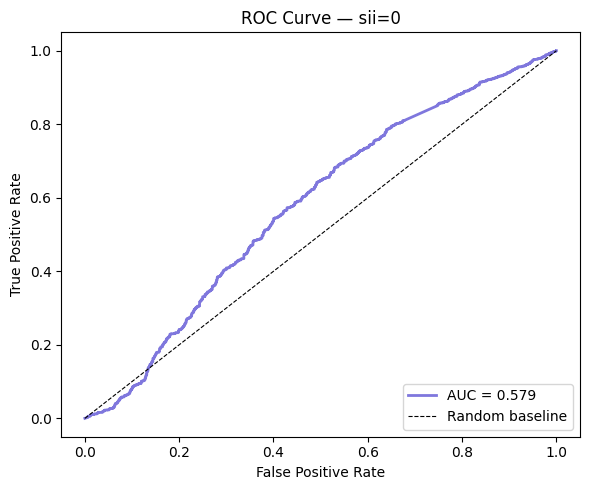

              precision    recall  f1-score   support

   not sii=0       0.39      0.48      0.43       777
       sii=0       0.74      0.66      0.70      1738

    accuracy                           0.60      2515
   macro avg       0.56      0.57      0.56      2515
weighted avg       0.63      0.60      0.61      2515


  Confusion Matrix breakdown:
    TN (correct negatives) : 374
    FP (false positives)   : 403
    FN (false negatives)   : 597
    TP (correct positives) : 1141
    AUC                    : 0.5793


In [75]:
models[0] = train_one_step_non_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=0')

In [76]:
# samples predicted as sii=0 → assign 0 to their original position
y_pred_te   = models[0].predict(X_te)

#----------------------------------
step_results[0] = {
    'step_name':    'sii=0 vs [1,2,3]',
    'y_true_bin':   y_binary_te.copy(),      # verdadero binario
    'y_pred_bin':   y_pred_te.copy(),        # predicho binario
    'y_true_orig':  y_te.copy(),             # verdadero multiclass en este paso
    'original_idx': original_idx.copy(),     # índices originales
}

y_pred_final[original_idx[y_pred_te == 1]] = 0

print(f"\n  Assigned as sii=0 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=0 : 1544 samples


### class 1 

In [77]:
# TRAIN → remove all true sii=0 
mask_tr      = y_tr != 0
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink index tracker too

In [78]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 1')
print_dist(y_te, 'TEST  after step 1')

  Remaining train : 1811
  Remaining test  : 1374

  SET: TRAIN after step 1
  Class  Count  Proportion  Percentage
sii=1.0   1097      0.6057       60.57
sii=2.0    655      0.3617       36.17
sii=3.0     59      0.0326        3.26

  SET: TEST  after step 1
  Class  Count  Proportion  Percentage
sii=0.0    597      0.4345       43.45
sii=1.0    470      0.3421       34.21
sii=2.0    281      0.2045       20.45
sii=3.0     26      0.0189        1.89


In [79]:
y_binary_tr = (y_tr == 1).astype(int)
y_binary_te = (y_te == 1).astype(int)

In [80]:
print_dist(y_binary_tr, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    714      0.3943       39.43
binary=1   1097      0.6057       60.57

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    904      0.6579       65.79
binary=1    470      0.3421       34.21


In [81]:
from imblearn.over_sampling import SMOTE
over_dic={0:900}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 1097, 0: 900})


In [82]:
print_dist(y_res, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    900      0.4507       45.07
binary=1   1097      0.5493       54.93

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    904      0.6579       65.79
binary=1    470      0.3421       34.21



  STEP: sii=1
  Training samples : 1997
  Positive class   : 1097 samples
  Negative class   : 900 samples



  Best params : {'kernel': 'poly', 'gamma': 'auto', 'degree': 5, 'coef0': 0.5, 'class_weight': 'balanced', 'C': 1}
  Best CV F1  : 0.6089
  Test F1     : 0.4945


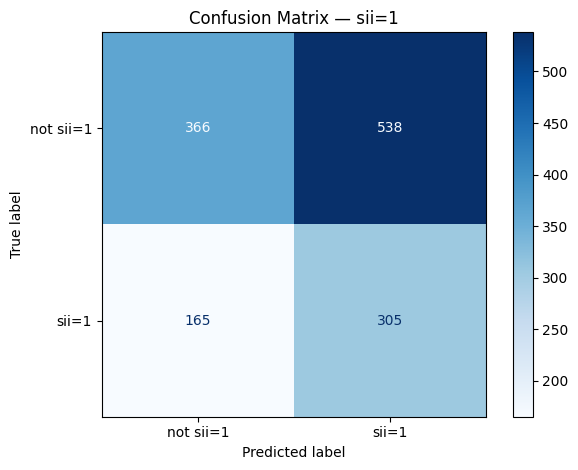

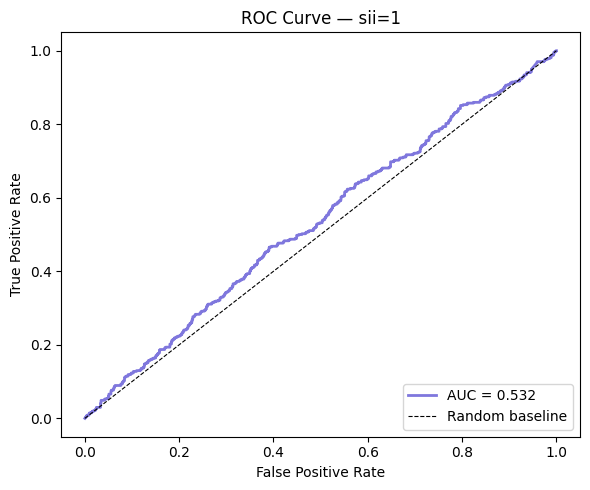

              precision    recall  f1-score   support

   not sii=1       0.69      0.40      0.51       904
       sii=1       0.36      0.65      0.46       470

    accuracy                           0.49      1374
   macro avg       0.53      0.53      0.49      1374
weighted avg       0.58      0.49      0.49      1374


  Confusion Matrix breakdown:
    TN (correct negatives) : 366
    FP (false positives)   : 538
    FN (false negatives)   : 165
    TP (correct positives) : 305
    AUC                    : 0.5322


In [83]:
models[1] = train_one_step_non_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=1')

In [84]:
y_pred_te   = models[1].predict(X_te)

step_results[1] = {
    'step_name':    'sii=1 vs [2,3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 1

print(f"\n  Assigned as sii=1 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=1 : 843 samples


### class 2

In [85]:
# TRAIN → remove all true sii=1
mask_tr      = y_tr != 1
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES 
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

In [86]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 2')
print_dist(y_te, 'TEST  after step 2')

  Remaining train : 714
  Remaining test  : 1069

  SET: TRAIN after step 2
  Class  Count  Proportion  Percentage
sii=2.0    655      0.9174       91.74
sii=3.0     59      0.0826        8.26

  SET: TEST  after step 2
  Class  Count  Proportion  Percentage
sii=0.0    597      0.5585       55.85
sii=1.0    165      0.1543       15.43
sii=2.0    281      0.2629       26.29
sii=3.0     26      0.0243        2.43


In [87]:
y_binary_tr = (y_tr == 2).astype(int)
y_binary_te = (y_te == 2).astype(int)

In [88]:
print_dist(y_binary_tr, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0     59      0.0826        8.26
binary=1    655      0.9174       91.74

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    788      0.7371       73.71
binary=1    281      0.2629       26.29


In [89]:
from imblearn.over_sampling import SMOTE
over_dic={0:500}
#under_dic={0:3000}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
#under = TomekLinks(sampling_strategy='majority')
X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
print('Resampled dataset shape %s' % Counter(y_res))


Resampled dataset shape Counter({1: 655, 0: 500})


In [90]:
print_dist(y_res, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0    500      0.4329       43.29
binary=1    655      0.5671       56.71

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    788      0.7371       73.71
binary=1    281      0.2629       26.29



  STEP: sii=2
  Training samples : 1155
  Positive class   : 655 samples
  Negative class   : 500 samples



  Best params : {'kernel': 'poly', 'gamma': 'auto', 'degree': 5, 'coef0': 0.5, 'class_weight': 'balanced', 'C': 1}
  Best CV F1  : 0.8912
  Test F1     : 0.3640


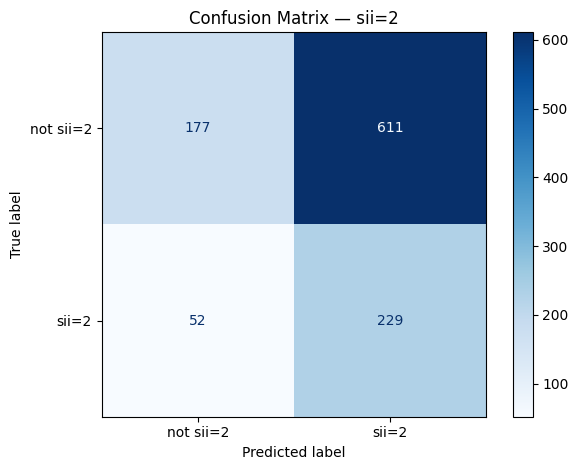

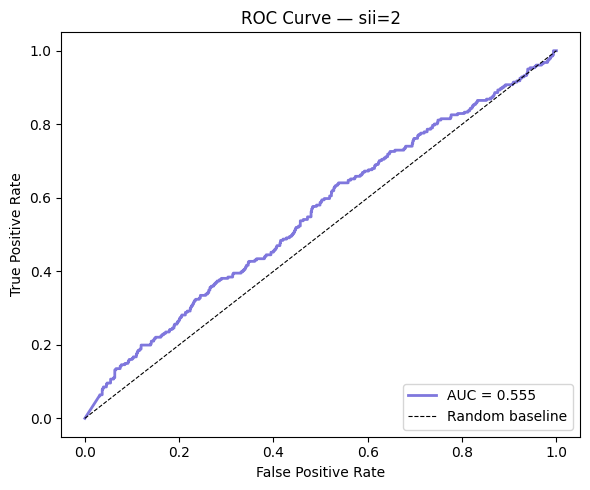

              precision    recall  f1-score   support

   not sii=2       0.77      0.22      0.35       788
       sii=2       0.27      0.81      0.41       281

    accuracy                           0.38      1069
   macro avg       0.52      0.52      0.38      1069
weighted avg       0.64      0.38      0.36      1069


  Confusion Matrix breakdown:
    TN (correct negatives) : 177
    FP (false positives)   : 611
    FN (false negatives)   : 52
    TP (correct positives) : 229
    AUC                    : 0.5549


In [91]:
models[2] = train_one_step_non_svm(X_res, y_res, X_te, y_binary_te,
                            step_name='sii=2')

In [92]:
# ── Assign predictions for step 3 ────────────────────────────────────────────
y_pred_te   = models[2].predict(X_te)

step_results[2] = {
    'step_name':    'sii=2 vs [3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 2

print(f"\n  Assigned as sii=2 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=2 : 840 samples


### class 3 

In [93]:
# ── Filter for next step ──────────────────────────────────────────────────────
mask_tr      = y_tr != 2
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")

  Remaining train : 59
  Remaining test  : 840


In [94]:
y_pred_final[original_idx] = 3
step_results[3] = {
    'step_name':    'sii=3 (remaining)',
    'y_true_bin':   (y_te == 3).astype(int),
    'y_pred_bin':   np.ones(len(y_te), dtype=int),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

print(f"\n  Assigned as sii=3 : {len(original_idx)} samples (all remaining)")


  Assigned as sii=3 : 840 samples (all remaining)


## RESULTS

In [95]:
# ══════════════════════════════════════════════════════════════════════════════
# REPORTE COMBINADO
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "="*75)
print("  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS")
print("="*75)

rows = []
for step, res in step_results.items():
    yt = res['y_true_bin']
    yp = res['y_pred_bin']

    # métricas binarias reales de cada paso
    prec   = precision_score(yt, yp, zero_division=0)
    rec    = recall_score(yt, yp, zero_division=0)
    f1     = f1_score(yt, yp, zero_division=0)
    n      = len(yt)
    n_pos  = yt.sum()
    tp     = ((yp == 1) & (yt == 1)).sum()
    fp     = ((yp == 1) & (yt == 0)).sum()
    fn     = ((yp == 0) & (yt == 1)).sum()

    rows.append({
        'Step':         res['step_name'],
        'N samples':    n,
        'N positive':   n_pos,
        'TP':           tp,
        'FP':           fp,
        'FN':           fn,
        'Precision':    round(prec, 4),
        'Recall':       round(rec,  4),
        'F1':           round(f1,   4),
    })

report_df = pd.DataFrame(rows)
print(report_df.to_string(index=False))


  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS
             Step  N samples  N positive   TP  FP  FN  Precision  Recall     F1
 sii=0 vs [1,2,3]       2515        1738 1141 403 597     0.7390  0.6565 0.6953
   sii=1 vs [2,3]       1374         470  305 538 165     0.3618  0.6489 0.4646
     sii=2 vs [3]       1069         281  229 611  52     0.2726  0.8149 0.4086
sii=3 (remaining)        840          26   26 814   0     0.0310  1.0000 0.0600


In [96]:
# ── Multiclass final ──────────────────────────────────────────────────────────
print("\n" + "="*75)
print("  FINAL MULTICLASS REPORT (y_test vs y_pred_final)")
print("="*75)
print(classification_report(
    y_test, y_pred_final,
    target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']
))


  FINAL MULTICLASS REPORT (y_test vs y_pred_final)
              precision    recall  f1-score   support

       sii=0       1.00      0.66      0.79      1738
       sii=1       1.00      0.65      0.79       470
       sii=2       1.00      0.81      0.90       281
       sii=3       0.03      1.00      0.06        26

    accuracy                           0.68      2515
   macro avg       0.76      0.78      0.63      2515
weighted avg       0.99      0.68      0.80      2515



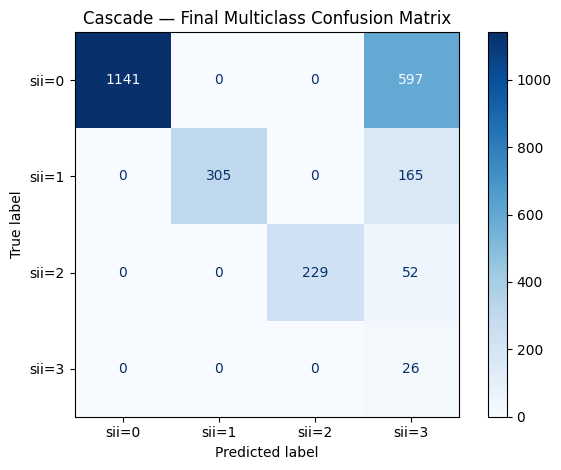

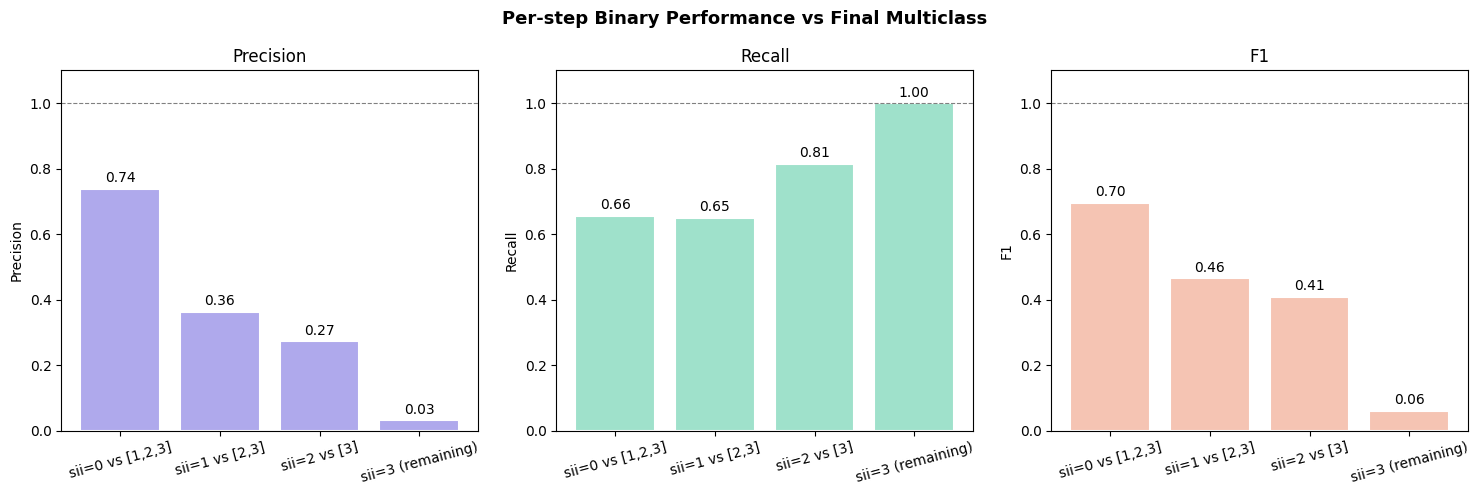

In [97]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['sii=0', 'sii=1', 'sii=2', 'sii=3']
)
disp.plot(cmap='Blues')
plt.title('Cascade — Final Multiclass Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Plot comparativo ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['Precision', 'Recall', 'F1']
colors    = ['#AFA9EC', '#9FE1CB', '#F5C4B3']

for ax, metric, color in zip(axes, metrics, colors):
    steps  = [r['Step'] for r in rows]
    values = [r[metric] for r in rows]
    bars   = ax.bar(steps, values, color=color, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle('Per-step Binary Performance vs Final Multiclass',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [98]:
# ── Per class summary ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  PREDICTIONS SUMMARY")
print(f"{'='*60}")
for cls in [0, 1, 2, 3]:
    true_count = (y_test == cls).sum()
    pred_count = (y_pred_final == cls).sum()
    print(f"  sii={cls} → true: {true_count:<6} predicted: {pred_count}")


  PREDICTIONS SUMMARY
  sii=0 → true: 1738   predicted: 1141
  sii=1 → true: 470    predicted: 305
  sii=2 → true: 281    predicted: 229
  sii=3 → true: 26     predicted: 840


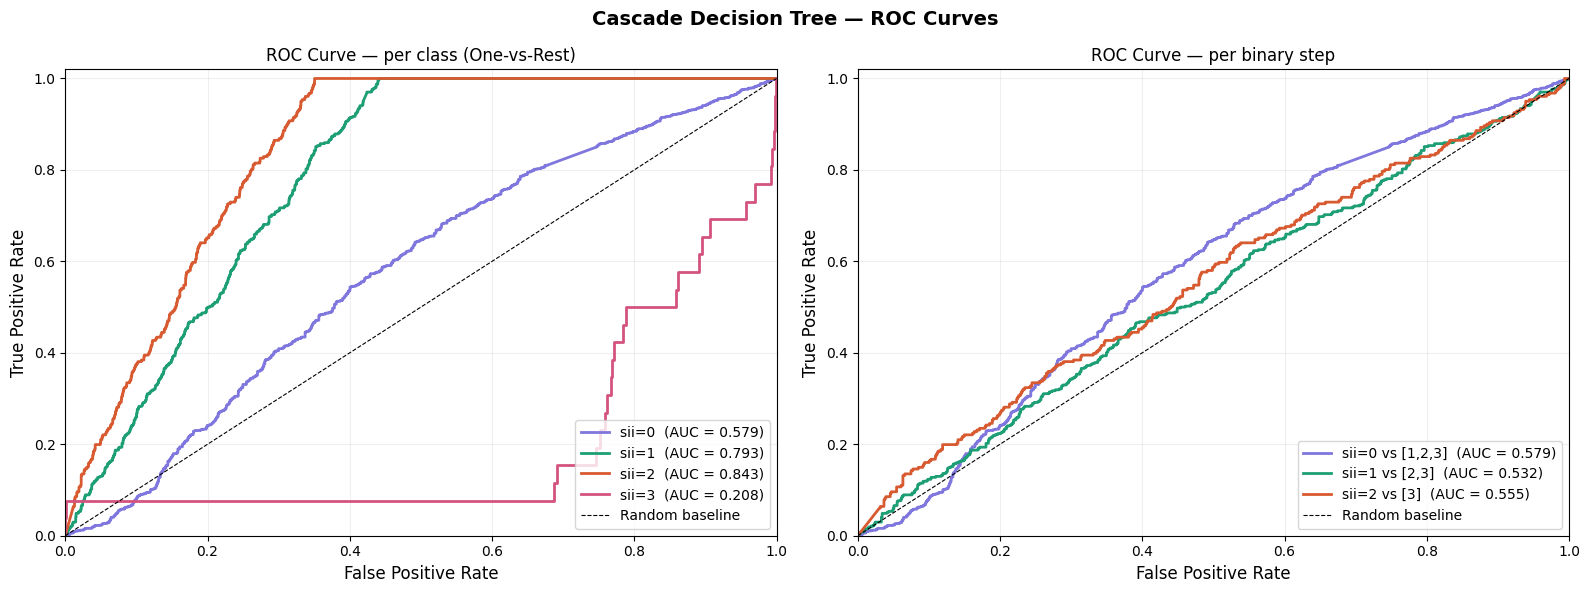


  AUC SUMMARY
  sii=0    → AUC = 0.5793
  sii=1    → AUC = 0.7932
  sii=2    → AUC = 0.8430
  sii=3    → AUC = 0.2078

  Macro AUC    : 0.6058
  Weighted AUC : 0.6449


In [99]:
# ── 1. Collect probabilities from each step ───────────────────────────────────
# Each model gives P(class=X) for the samples it saw
# We need to reconstruct full probability matrix (n_test, 4)

n_test     = len(X_test)
proba_full = np.zeros((n_test, 4))   # one column per class

for step, res in step_results.items():
    idx    = res['original_idx']          # which original test samples this step saw
    model  = models.get(step)

    if model is not None:
        proba_step         = model.predict_proba(X_test[idx])   # shape (n_step, 2)
        proba_full[idx, step] = proba_step[:, 1]                # P(positive) for this class
    else:
        # last class — use survival probability (1 - sum of previous)
        proba_full[idx, step] = 1 - proba_full[idx, :step].sum(axis=1)

# ── 2. Binarize y_test for multiclass ROC ────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # shape (n_test, 4)

# ── 3. Compute ROC per class ──────────────────────────────────────────────────
colors     = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E']
step_names = ['sii=0', 'sii=1', 'sii=2', 'sii=3']

fpr_dict = {}
tpr_dict = {}
auc_dict = {}

for i in range(4):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], proba_full[:, i])
    auc_dict[i]                  = auc(fpr_dict[i], tpr_dict[i])

# ── 4. Plot — two panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1 — individual ROC per class ───────────────────────────────────────
ax = axes[0]
for i in range(4):
    ax.plot(fpr_dict[i], tpr_dict[i],
            color=colors[i],
            linewidth=2,
            label=f"{step_names[i]}  (AUC = {auc_dict[i]:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per class (One-vs-Rest)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

# ── Panel 2 — step by step binary ROC ────────────────────────────────────────
ax = axes[1]
for step, res in step_results.items():
    model = models.get(step)
    if model is None:
        continue                              # skip last class (no model)

    idx        = res['original_idx']
    y_true_bin = res['y_true_bin']
    y_proba    = model.predict_proba(X_test[idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_true_bin, y_proba)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=colors[step],
            linewidth=2,
            label=f"{step_results[step]['step_name']}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per binary step', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

plt.suptitle('Cascade Decision Tree — ROC Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Print AUC summary ──────────────────────────────────────────────────────
print("\n" + "="*45)
print("  AUC SUMMARY")
print("="*45)
for i in range(4):
    print(f"  {step_names[i]:<8} → AUC = {auc_dict[i]:.4f}")

from sklearn.metrics import roc_auc_score
macro    = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='macro')
weighted = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='weighted')
print(f"\n  Macro AUC    : {macro:.4f}")
print(f"  Weighted AUC : {weighted:.4f}")
print("="*45)

# NON LINEAR SVM

  RANDOM SEARCH — SVM non lineare
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/alicecalderini/opt/anaconda3/lib/


── Best hyperparameters found ──────────────────────────
  kernel         : sigmoid
  gamma          : auto
  coef0          : 0
  class_weight   : balanced
  C              : 1

  F1-weighted (CV): 0.3618

── Classification Report (Test set) ───────────────────────
              precision    recall  f1-score   support

         0.0       0.84      0.11      0.20      1738
         1.0       0.18      0.43      0.25       470
         2.0       0.14      0.48      0.21       281
         3.0       0.01      0.04      0.01        26

    accuracy                           0.21      2515
   macro avg       0.29      0.26      0.17      2515
weighted avg       0.63      0.21      0.21      2515

  F1-weighted (Test):  0.2052
  F1-weighted (CV):    0.3618
  Delta CV→Test:       -0.1565  (attenzione: possibile overfitting)


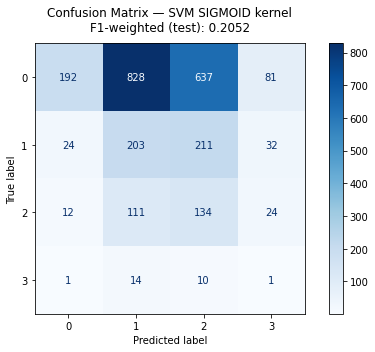


  Confusion matrix salvata in confusion_matrix_svm.png


In [ ]:
# ── Parametri globali ────────────────────────────────────────────────────────
random_state = 42
n_splits     = 5
n_iter       = 30

# ── Spazio di ricerca ────────────────────────────────────────────────────────
param_list = [
    # RBF kernel
    {
        "C":            [0.001, 0.01, 0.1, 1],
        "kernel":       ["rbf"],
        "gamma":        ["auto"],
        "class_weight": ["balanced"],
    },
    # Polynomial kernel
    {
        "C":            [0.001, 0.01, 0.1, 1],
        "kernel":       ["poly"],
        "gamma":        ["auto"],
        "degree":       [2, 3, 4, 5],
        "coef0":        [0, 0.1, 0.5],
        "class_weight": ["balanced"],
    },
    # Sigmoid kernel
    {
        "C":            [0.001, 0.01, 0.1, 1],
        "kernel":       ["sigmoid"],
        "gamma":        ["auto"],
        "coef0":        [0, 0.1],
        "class_weight": ["balanced"],
    },
]

"""over_dic={1:1500, 2:1500, 3:500}
over = SMOTE(random_state=42, sampling_strategy=over_dic)
X_res, y_res = over.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))"""

# ── Random Search ────────────────────────────────────────────────────────────
print("=" * 60)
print("  RANDOM SEARCH — SVM non lineare")
print("=" * 60)

random_search = RandomizedSearchCV(
    SVC(probability=True, random_state=random_state, max_iter=2000),
    param_distributions=param_list,
    cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
    scoring="f1_weighted",
    n_jobs=-1,
    refit=True,          # riaddestra automaticamente sul dataset completo
    n_iter=n_iter,
    random_state=random_state,
    verbose=1,
)

random_search.fit(X_train, y_train)

# ── Risultati della ricerca ──────────────────────────────────────────────────
print("\n── Best hyperparameters found ──────────────────────────")
for param, value in random_search.best_params_.items():
    print(f"  {param:<15}: {value}")

print(f"\n  F1-weighted (CV): {random_search.best_score_:.4f}")

# ── Modello migliore (già refit sul training set completo) ───────────────────
best_model = random_search.best_estimator_

# ── Previsioni sul test set ──────────────────────────────────────────────────
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)   # probabilità per classe

# ── Metriche ─────────────────────────────────────────────────────────────────
print("\n── Classification Report (Test set) ───────────────────────")
print(classification_report(y_test, y_pred))

f1_test = f1_score(y_test, y_pred, average="weighted")
print(f"  F1-weighted (Test):  {f1_test:.4f}")
print(f"  F1-weighted (CV):    {random_search.best_score_:.4f}")
delta = f1_test - random_search.best_score_
print(f"  Delta CV→Test:       {delta:+.4f}  {'(ok)' if abs(delta) < 0.05 else '(attenzione: possibile overfitting)'}")

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title(
    f"Confusion Matrix — SVM {random_search.best_params_['kernel'].upper()} kernel\n"
    f"F1-weighted (test): {f1_test:.4f}",
    fontsize=12,
    pad=12,
)
plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=150)
plt.show()
print("\n  Confusion matrix salvata in confusion_matrix_svm.png")